In [ ]:
!pip install nltk wordcloud scikit-learn seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "ziya07/contextual-sentiment-feedback-dataset"
)

print("Dataset location:", path)

Using Colab cache for faster access to the 'contextual-sentiment-feedback-dataset' dataset.
Dataset location: /kaggle/input/contextual-sentiment-feedback-dataset


In [ ]:
import os
print(os.listdir(path))

['.nfs0000000051056490000000a8', 'student_feedback_dataset.csv']


In [ ]:
csv_files = [
    file for file in os.listdir(path)
    if file.endswith('.csv')
]

print("CSV files:", csv_files)

CSV files: ['student_feedback_dataset.csv']


In [ ]:
file_path = os.path.join(path, csv_files[0])

df = pd.read_csv(file_path)

df.head()

,student_id,department,subject_name,feedback_text,preprocessed_text,sentiment_label,sarcasm_flag,emotion_tag,feedback_type,subject_specific_context,response_required
0,STU0001,CIVIL,Concrete Tech,Attack medical dog technology top several insi...,attack medical dog technology top several insi...,negative,0,anger,Infrastructure,Project-Based,1
1,STU0002,CIVIL,Concrete Tech,Wait worry speak program child past beautiful ...,wait worry speak program child past beautiful ...,positive,0,anger,Infrastructure,Lab-Intensive,0
2,STU0003,BIO,Genetics,Bank those report box your treatment accept in...,bank those report box your treatment accept in...,neutral,0,sadness,Academic,Project-Based,1
3,STU0004,ME,Fluid Mechanics,Can character million listen right amount ask ...,can character million listen right amount ask ...,positive,0,joy,Academic,Theory-Heavy,0
4,STU0005,ME,Fluid Mechanics,Good cost political street dream finish figure.,good cost political street dream finish figure,negative,0,surprise,Academic,Theory-Heavy,1


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

print("\nDataset Information:")
df.info()

Dataset Shape: (1223, 11)

Columns:
['student_id', 'department', 'subject_name', 'feedback_text', 'preprocessed_text', 'sentiment_label', 'sarcasm_flag', 'emotion_tag', 'feedback_type', 'subject_specific_context', 'response_required']

Missing Values:
student_id                  0
department                  0
subject_name                0
feedback_text               0
preprocessed_text           0
sentiment_label             0
sarcasm_flag                0
emotion_tag                 0
feedback_type               0
subject_specific_context    0
response_required           0
dtype: int64

Duplicate Records:
0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1223 entries, 0 to 1222
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   student_id                1223 non-null   object
 1   department                1223 non-null   object
 2   subject_name              1223 no

In [ ]:
df[['feedback_text']].head(10)

,feedback_text
0,Attack medical dog technology top several insi...
1,Wait worry speak program child past beautiful ...
2,Bank those report box your treatment accept in...
3,Can character million listen right amount ask ...
4,Good cost political street dream finish figure.
5,Month leave doctor single vote say reach be sk...
6,Measure challenge series material I history le...
7,Small message what executive certain evidence ...
8,Civil eat memory become beyond interview fall ...
9,Machine tend simply beat which when remain why...


In [ ]:
df = df.dropna(subset=['feedback_text'])

df = df.drop_duplicates(subset=['feedback_text'])

df = df.reset_index(drop=True)

print("Dataset after cleaning:", df.shape)

Dataset after cleaning: (1223, 11)


In [ ]:
import string
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    # Convert to lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Tokenization
    words = word_tokenize(text)

    # Stopword removal + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
        and len(word) > 1
    ]

    return ' '.join(words)

In [ ]:
df['cleaned_feedback'] = df['feedback_text'].apply(
    preprocess_text
)

df[
    ['feedback_text', 'cleaned_feedback']
].head(10)

,feedback_text,cleaned_feedback
0,Attack medical dog technology top several insi...,attack medical dog technology top several insi...
1,Wait worry speak program child past beautiful ...,wait worry speak program child past beautiful ...
2,Bank those report box your treatment accept in...,bank report box treatment accept interesting p...
3,Can character million listen right amount ask ...,character million listen right amount ask scor...
4,Good cost political street dream finish figure.,good cost political street dream finish figure
5,Month leave doctor single vote say reach be sk...,month leave doctor single vote say reach skin ...
6,Measure challenge series material I history le...,measure challenge series material history leas...
7,Small message what executive certain evidence ...,small message executive certain evidence way m...
8,Civil eat memory become beyond interview fall ...,civil eat memory become beyond interview fall ...
9,Machine tend simply beat which when remain why...,machine tend simply beat remain reason two simply


In [ ]:
print(df['sentiment_label'].value_counts())

sentiment_label
positive    489
neutral     368
negative    366
Name: count, dtype: int64


In [ ]:
df['sentiment_label'] = (
    df['sentiment_label']
    .astype(str)
    .str.lower()
    .str.strip()
)

print(df['sentiment_label'].value_counts())

sentiment_label
positive    489
neutral     368
negative    366
Name: count, dtype: int64


In [ ]:
sentiment_counts = df['sentiment_label'].value_counts()

sentiment_percentage = (
    df['sentiment_label']
    .value_counts(normalize=True) * 100
)

print("Sentiment Counts:")
print(sentiment_counts)

print("\nSentiment Percentage:")
print(sentiment_percentage.round(2))

Sentiment Counts:
sentiment_label
positive    489
neutral     368
negative    366
Name: count, dtype: int64

Sentiment Percentage:
sentiment_label
positive    39.98
neutral     30.09
negative    29.93
Name: proportion, dtype: float64


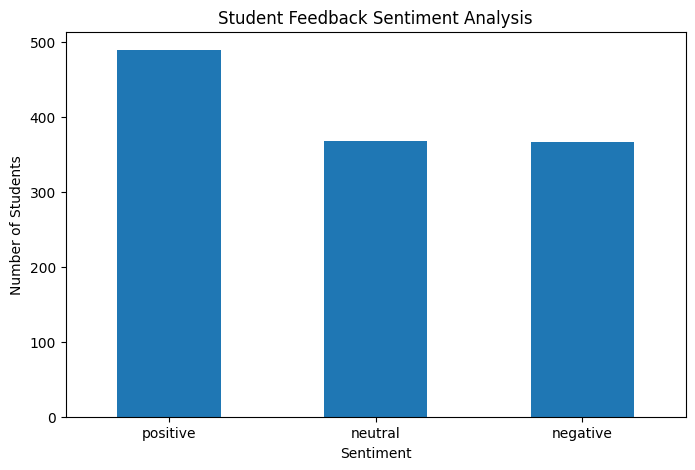

In [ ]:
plt.figure(figsize=(8, 5))

sentiment_counts.plot(kind='bar')

plt.title("Student Feedback Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

plt.show()

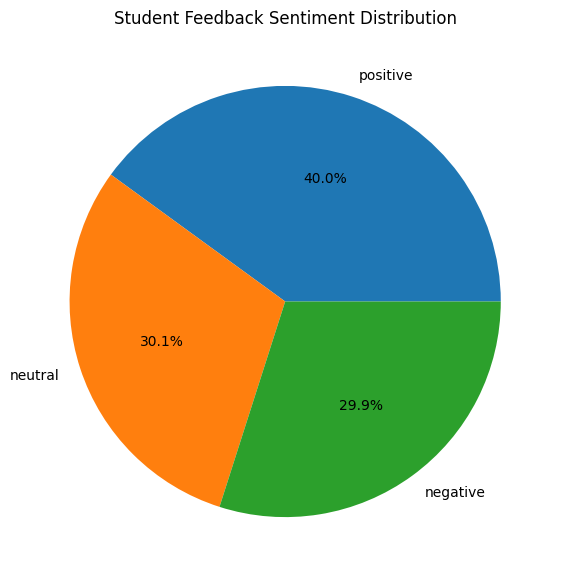

In [ ]:
sentiment_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7, 7)
)

plt.title("Student Feedback Sentiment Distribution")
plt.ylabel("")

plt.show()

In [ ]:
concern_keywords = {

    'Teaching': [
        'teacher', 'teaching', 'faculty',
        'professor', 'instructor', 'explain',
        'explanation', 'lecture'
    ],

    'Course Content': [
        'course', 'content', 'syllabus',
        'topic', 'subject', 'curriculum'
    ],

    'Assessment': [
        'exam', 'test', 'assignment',
        'assessment', 'marks', 'grade',
        'grading'
    ],

    'Classroom Activities': [
        'activity', 'activities',
        'discussion', 'interaction',
        'classroom', 'practical'
    ],

    'Infrastructure': [
        'classroom', 'lab', 'wifi',
        'internet', 'facility',
        'facilities', 'equipment'
    ],

    'Learning Resources': [
        'notes', 'material', 'materials',
        'book', 'library', 'resource',
        'resources'
    ]
}

In [ ]:
negative_df = df[
    df['sentiment_label'] == 'negative'
].copy()

print("Total Negative Feedback:", len(negative_df))

negative_df[
    ['feedback_text', 'sentiment_label']
].head(10)

Total Negative Feedback: 366


,feedback_text,sentiment_label
0,Attack medical dog technology top several insi...,negative
4,Good cost political street dream finish figure.,negative
5,Month leave doctor single vote say reach be sk...,negative
8,Civil eat memory become beyond interview fall ...,negative
9,Machine tend simply beat which when remain why...,negative
16,Indeed scene their this fast Mrs decision turn...,negative
18,Camera stand war land present though feel gas ...,negative
19,Attorney only goal turn time through.,negative
21,Challenge store notice law plan position dark ...,negative
28,Trouble reveal when around center result outsi...,negative


In [ ]:
concern_counts = {}

for concern, keywords in concern_keywords.items():

    count = 0

    for text in negative_df['cleaned_feedback']:

        text = str(text).lower()

        if any(keyword in text for keyword in keywords):
            count += 1

    concern_counts[concern] = count

print(concern_counts)

{'Teaching': 22, 'Course Content': 10, 'Assessment': 7, 'Classroom Activities': 6, 'Infrastructure': 4, 'Learning Resources': 8}


In [ ]:
concern_df = pd.DataFrame(
    list(concern_counts.items()),
    columns=['Student Concern', 'Number of Complaints']
)

concern_df = concern_df.sort_values(
    by='Number of Complaints',
    ascending=False
)

concern_df

,Student Concern,Number of Complaints
0,Teaching,22
1,Course Content,10
5,Learning Resources,8
2,Assessment,7
3,Classroom Activities,6
4,Infrastructure,4


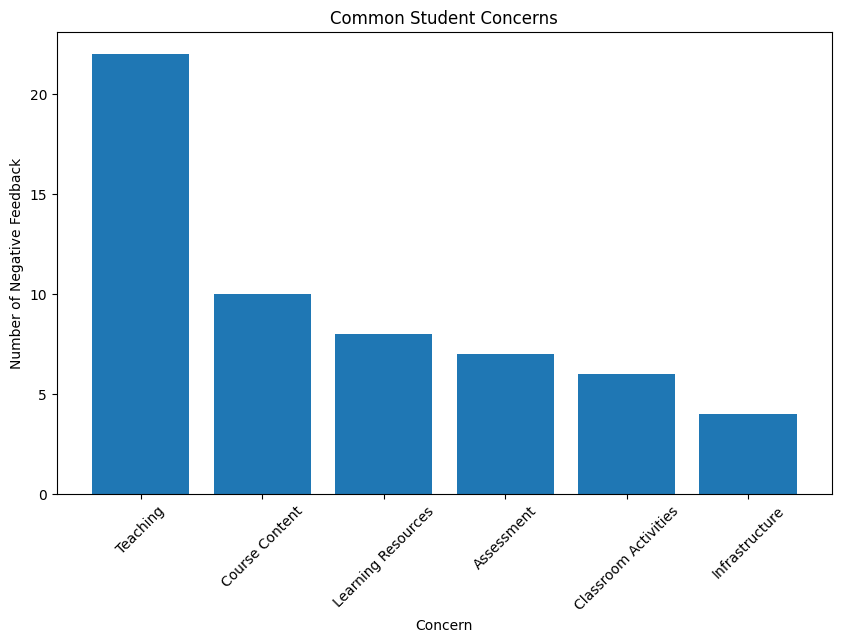

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    concern_df['Student Concern'],
    concern_df['Number of Complaints']
)

plt.title("Common Student Concerns")
plt.xlabel("Concern")
plt.ylabel("Number of Negative Feedback")

plt.xticks(rotation=45)

plt.show()

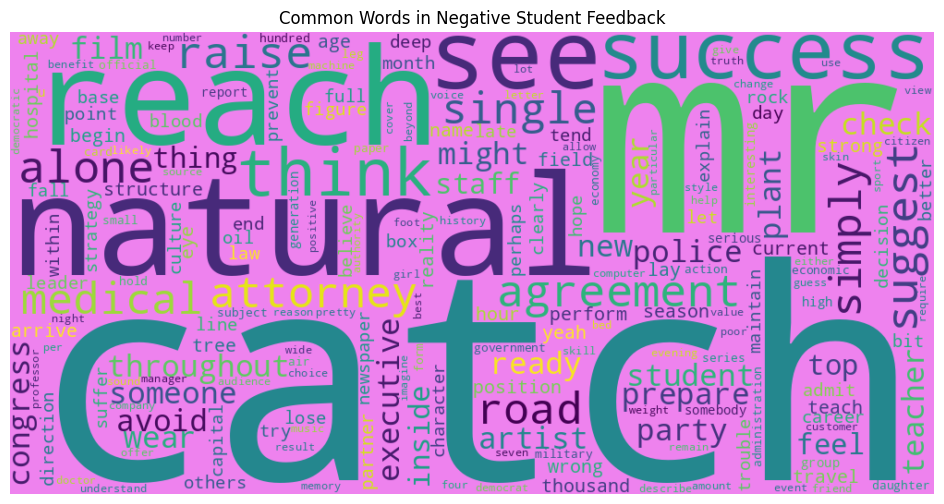

In [ ]:
negative_text = ' '.join(
    negative_df['cleaned_feedback'].astype(str)
)

if negative_text.strip():

    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color='violet'
    ).generate(negative_text)

    plt.figure(figsize=(12, 6))

    plt.imshow(
        wordcloud,
        interpolation='bilinear'
    )

    plt.axis('off')

    plt.title(
        "Common Words in Negative Student Feedback"
    )

    plt.show()

In [ ]:
from collections import Counter

all_words = ' '.join(
    negative_df['cleaned_feedback']
).split()

word_counts = Counter(all_words)

common_words = word_counts.most_common(15)

common_words_df = pd.DataFrame(
    common_words,
    columns=['Word', 'Frequency']
)

common_words_df

,Word,Frequency
0,catch,14
1,mr,12
2,natural,12
3,reach,11
4,see,11
5,success,10
6,think,10
7,agreement,10
8,alone,10
9,raise,10


In [ ]:
suggestions = {

    'Teaching':
        'Improve teaching methods, explanations and faculty-student interaction.',

    'Course Content':
        'Review and update course content based on student learning requirements.',

    'Assessment':
        'Improve assessment methods and provide clear and timely feedback.',

    'Classroom Activities':
        'Introduce more interactive discussions, practical activities and group work.',

    'Infrastructure':
        'Improve classroom, laboratory, internet and other campus facilities.',

    'Learning Resources':
        'Provide better notes, study materials, library resources and online resources.'
}

In [ ]:
print("STUDENT FEEDBACK IMPROVEMENT SUGGESTIONS")
print("=" * 55)

for _, row in concern_df.iterrows():

    concern = row['Student Concern']
    count = row['Number of Complaints']

    print(f"\n{concern}")
    print("Complaints:", count)
    print("Suggestion:", suggestions[concern])

STUDENT FEEDBACK IMPROVEMENT SUGGESTIONS

Teaching
Complaints: 22
Suggestion: Improve teaching methods, explanations and faculty-student interaction.

Course Content
Complaints: 10
Suggestion: Review and update course content based on student learning requirements.

Learning Resources
Complaints: 8
Suggestion: Provide better notes, study materials, library resources and online resources.

Assessment
Complaints: 7
Suggestion: Improve assessment methods and provide clear and timely feedback.

Classroom Activities
Complaints: 6
Suggestion: Introduce more interactive discussions, practical activities and group work.

Infrastructure
Complaints: 4
Suggestion: Improve classroom, laboratory, internet and other campus facilities.


In [ ]:
major_concern = max(
    concern_counts,
    key=concern_counts.get
)

print("MAJOR STUDENT CONCERN")
print("---------------------")
print(major_concern)

print("\nRECOMMENDATION")
print("--------------")
print(suggestions[major_concern])

MAJOR STUDENT CONCERN
---------------------
Teaching

RECOMMENDATION
--------------
Improve teaching methods, explanations and faculty-student interaction.


In [ ]:
total = len(df)

positive = (
    df['sentiment_label'] == 'positive'
).sum()

negative = (
    df['sentiment_label'] == 'negative'
).sum()

neutral = (
    df['sentiment_label'] == 'neutral'
).sum()

print("=" * 50)
print("STUDENT FEEDBACK ANALYSIS REPORT")
print("=" * 50)

print("\nTotal Feedback:", total)

print(
    f"Positive: {positive} "
    f"({positive/total*100:.2f}%)"
)

print(
    f"Negative: {negative} "
    f"({negative/total*100:.2f}%)"
)

print(
    f"Neutral: {neutral} "
    f"({neutral/total*100:.2f}%)"
)

print("\nMajor Concern:", major_concern)

print(
    "\nImprovement Suggestion:",
    suggestions[major_concern]
)

STUDENT FEEDBACK ANALYSIS REPORT

Total Feedback: 1223
Positive: 489 (39.98%)
Negative: 366 (29.93%)
Neutral: 368 (30.09%)

Major Concern: Teaching

Improvement Suggestion: Improve teaching methods, explanations and faculty-student interaction.
